# Assignment: Trees

## Do two questions in total: "Q1+Q2" or "Q1+Q3"

`! git clone https://github.com/ds3001f25/linear_models_assignment.git`

**Q1.** Please answer the following questions in your own words.
1. Why is the Gini a good loss function for categorical target variables?
2. Why do trees tend to overfit, and how can this tendency be constrained?
3. True or false, and explain: Trees only really perform well in situations with lots of categorical variables as features/covariates.
4. Why don't most versions of classification/regression tree concept allow for more than two branches after a split?
5. What are some heuristic ways you can examine a tree and decide whether it is probably over- or under-fitting?

In [17]:
! git clone https://github.com/ds3001f25/trees_assignment.git
#I would like to acknolwedge use of CHATGPT as aid in completing this assignment. It was of particular use in formulating code and intuition behind many of the answers to the questions.

fatal: destination path 'trees_assignment' already exists and is not an empty directory.


In [18]:
rm -rf /content/linear_models_assignment

#1 Gini Impurity Measures how mixed the classes are in a node. This is a good loss function for categorical variables because it is good for greedy algorithms and it penalizes impurity more than other models. Both these reasons make gini impurity the best test to measure impurity.

#2-Trees tend to overfit because they split to much, which tends to capture noise instead of integral characteristics of the data. This is done in cases where leaf purity is emphasized, instead of a simpler generalization. This tendency can be constrained by truncating the tree and limiting its depth.

#3- False. Trees perform very well with numerical variables. In fact, running trees with numerical variables can even tell us more in some cases than categorical variables. An example from my personal experience was in my COMM class we ran a decision tree to figure out numeric variable weight in survavability of those who boarded the titanic. Variables like number of siblings, income, and age, were crucial and integral in making the model useful.

#4- Splitting decision trees into more than binary groups is often discoruaged and inaccesible. This could be because the tree has implicit designs to discourage overfitting, which could happen if we were able to split the data into more than two trees. Splitting into two branches makes the data more simple and efficient and thus easier to interpret. These factors all contribute to the reason why most classification/regression tree concepts only enable dual branch splitting.

#5- Gini impurity and Entropy are both methods to look at how mixed or impure each branch is of a decision tree but this doesn't directly answer the question of overfitting and underfitting. One way we can observe potential overfitting and underfitting is the length of a tree. A shallow tree implies a underfit whereas a very deep tree implies an overfit. The total amount of leaves also relate to a sense of overfitting and underfitting. A lot of leaves imply an underfit, whereas a small number of leaves but a large depth alludes to an overfit. Underfit models tend to be too simple whereas overfit models tend to be to specific. Another way to observe potential fitting issues of the model is the basis for splitting. If the model splits on random and irrelevant things, than it is a overfit. If the model splits on basic characteristics, then it is underfit.

**Q2.** This is a case study about classification and regression trees.

1. Load the `Breast Cancer METABRIC.csv` dataset. How many observations and variables does it contain? Print out the first few rows of data.

2.  We'll use a consistent set of feature/explanatory variables. For numeric variables, we'll include `Tumor Size`, `Lymph nodes examined positive`, `Age at Diagnosis`. For categorical variables, we'll include `Tumor Stage`, `Chemotherapy`, and `Cancer Type Detailed`. One-hot-encode the categorical variables and concatenate them with the numeric variables into a feature/covariate matrix, $X$.

3. Let's predict `Overall Survival Status` given the features/covariates $X$. There are 528 missing values, unfortunately: Either drop those rows from your data or add them as a category to predict. Constrain the minimum samples per leaf to 10. Print a dendrogram of the tree. Print a confusion matrix of the algorithm's performance. What is the accuracy?

4. For your model in part three, compute three statistics:
    - The **true positive rate** or **sensitivity**:
        $$
        TPR = \dfrac{TP}{TP+FN}
        $$
    - The **true negative rate** or **specificity**:
        $$
        TNR = \dfrac{TN}{TN+FP}
        $$
    Does your model tend to perform better with respect to one of these metrics?

5. Let's predict `Overall Survival (Months)` given the features/covariates $X$. Use the train/test split to pick the optimal `min_samples_leaf` value that gives the highest $R^2$ on the test set (it's about 110). What is the $R^2$? Plot the test values against the predicted values. How do you feel about this model for clinical purposes?

**Q3.** This is a case study about trees using bond rating data. This is a dataset about bond ratings for different companies, alongside a bunch of business statistics and other data. Companies often have multiple reviews at different dates. We want to predict the bond rating (AAA, AA, A, BBB, BB, B, ..., C, D). Do business fundamentals predict the company's rating?

1. Load the `./data/corporate_ratings.csv` dataset. How many observations and variables does it contain? Print out the first few rows of data.

2.  Plot a histogram of the `ratings` variable. It turns out that the gradations of AAA/AA/A and BBB/BB/B and so on make it hard to get good results with trees. Collapse all AAA/AA/A ratings into just A, and similarly for B and C.

3. Use all of the variables **except** Rating, Date, Name, Symbol, and Rating Agency Name. To include Sector, make a dummy/one-hot-encoded representation and include it in your features/covariates. Collect the relevant variables into a data matrix $X$.

4. Do a train/test split of the data and use a decision tree classifier to predict the bond rating. Including a min_samples_leaf constraint can raise the accuracy and speed up computation time. Print a confusion matrix and the accuracy of your model. How well do you predict the different bond ratings?

5. If you include the rating agency as a feature/covariate/predictor variable, do the results change? How do you interpret this?

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
#1
data=pd.read_csv('/content/trees_assignment/data/corporate_ratings.csv')

# No. of observations and variables
data.shape

#The data has 2029 rows and 31 columns

#First 5 Rows
data.head()



,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,11/27/2015,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2/13/2014,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,3/6/2015,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,6/15/2012,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,10/24/2016,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


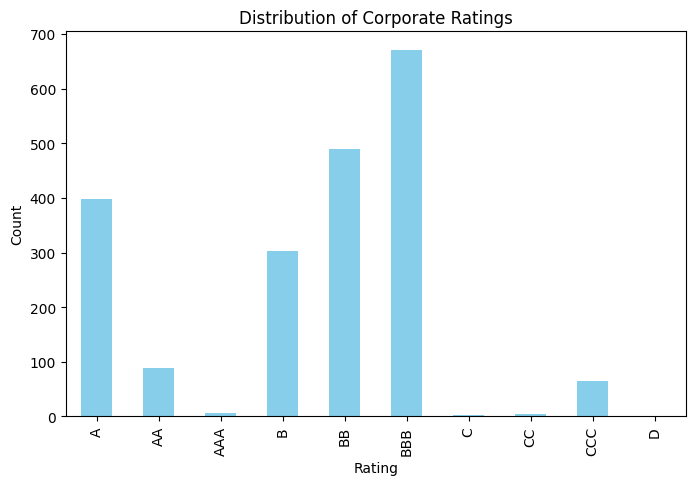

In [21]:
#2- Histogram
# Plot histogram (counts of each rating)
plt.figure(figsize=(8,5))
data['Rating'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribution of Corporate Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

Rating_Collapsed
B    1463
A     494
C      71
D       1
Name: count, dtype: int64


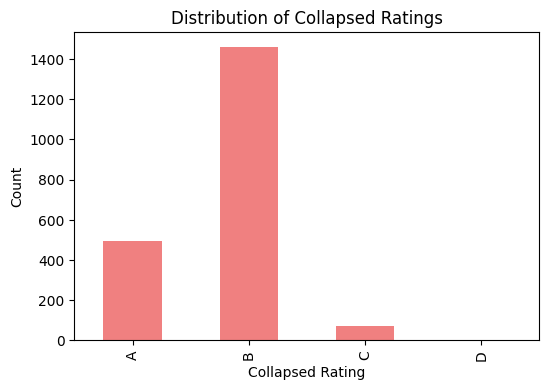

In [22]:
#2- Collapsing Ratings
collapse_map = {
    'AAA': 'A', 'AA': 'A', 'A': 'A',
    'BBB': 'B', 'BB': 'B', 'B': 'B',
    'CCC': 'C', 'CC': 'C', 'C': 'C'
}

data['Rating_Collapsed'] = data['Rating'].replace(collapse_map)

# Check results
print(data['Rating_Collapsed'].value_counts())

# Plot collapsed ratings
plt.figure(figsize=(6,4))
data['Rating_Collapsed'].value_counts().sort_index().plot(kind='bar', color='lightcoral')
plt.title('Distribution of Collapsed Ratings')
plt.xlabel('Collapsed Rating')
plt.ylabel('Count')
plt.show()

In [25]:
#3- Dropping Variables and Creating a Matrix
drop_cols = ['Rating', 'Date', 'Name', 'Symbol', 'Rating Agency Name']
features = data.drop(columns=drop_cols)

# One-hot encode the 'Sector' column
X = pd.get_dummies(features, columns=['Sector'], drop_first=True)
y = data['Rating_Collapsed']


# Display shape and first few rows
print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (2029, 37)


,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,returnOnCapitalEmployed,...,Sector_Consumer Durables,Sector_Consumer Non-Durables,Sector_Consumer Services,Sector_Energy,Sector_Finance,Sector_Health Care,Sector_Miscellaneous,Sector_Public Utilities,Sector_Technology,Sector_Transportation
0,0.945894,0.426395,0.099690,44.203245,0.037480,0.049351,0.176631,0.061510,0.041189,0.091514,...,True,False,False,False,False,False,False,False,False,False
1,1.033559,0.498234,0.203120,38.991156,0.044062,0.048857,0.175715,0.066546,0.053204,0.104800,...,True,False,False,False,False,False,False,False,False,False
2,0.963703,0.451505,0.122099,50.841385,0.032709,0.044334,0.170843,0.059783,0.032497,0.075955,...,True,False,False,False,False,False,False,False,False,False
3,1.019851,0.510402,0.176116,41.161738,0.020894,-0.012858,0.138059,0.042430,0.025690,-0.027015,...,True,False,False,False,False,False,False,False,False,False
4,0.957844,0.495432,0.141608,47.761126,0.042861,0.053770,0.177720,0.065354,0.046363,0.096945,...,True,False,False,False,False,False,False,False,False,False


In [30]:
#3 Cleaning data
print(y.value_counts())

# Keep only classes with at least 2 observations
valid_classes = y.value_counts()[y.value_counts() >= 2].index
mask = y.isin(valid_classes)

X = X[mask]
y = y[mask]


Rating_Collapsed
B    1463
A     494
C      71
D       1
Name: count, dtype: int64


Index([], dtype='object')
Accuracy: 0.742

Classification Report:
               precision    recall  f1-score   support

           A       0.55      0.56      0.55       149
           B       0.81      0.83      0.82       439
           C       0.40      0.19      0.26        21

    accuracy                           0.74       609
   macro avg       0.59      0.53      0.54       609
weighted avg       0.74      0.74      0.74       609



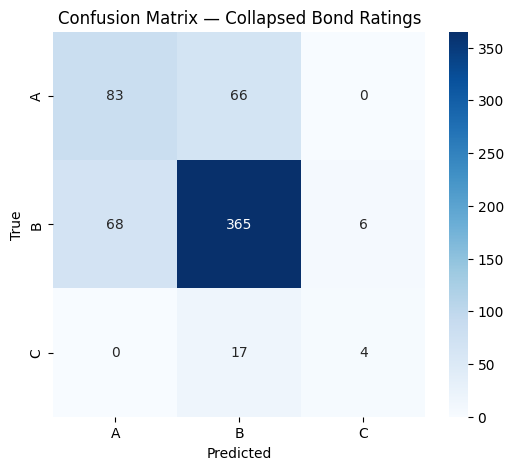

In [33]:
#4-Splitting Into Test and Training Sets


X = X.drop(columns=['Rating_Collapsed'], errors='ignore')


print(X.select_dtypes(include='object').columns)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train a Decision Tree
tree = DecisionTreeClassifier(random_state=42, min_samples_leaf=10)
tree.fit(X_train, y_train)

# Predictions
y_pred = tree.predict(X_test)

# Evaluate performance
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=tree.classes_,
            yticklabels=tree.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Collapsed Bond Ratings")
plt.show()

#4- My model was 74.2% accurate in predicting bond ratings. My model was far better at predicting 'B' level bonds than 'A' and 'C' level bonds. For example, A bonds had a precision of 55%, B bonds had a precision of 81% and C bonds had a precision of 40%.

Accuracy (with Rating Agency included): 0.749

Classification Report:
               precision    recall  f1-score   support

           A       0.57      0.60      0.58       149
           B       0.83      0.83      0.83       439
           C       0.27      0.14      0.19        21

    accuracy                           0.75       609
   macro avg       0.56      0.52      0.53       609
weighted avg       0.74      0.75      0.75       609



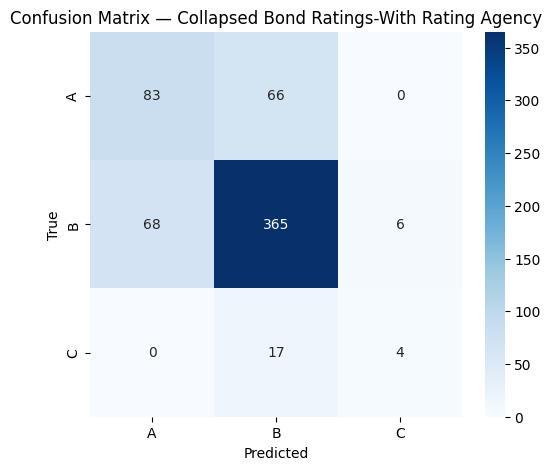

In [37]:
#5- adding agency name as predictor

# Define target
y = data['Rating_Collapsed']

# Keep all variables except those we’re told to exclude
X2 = data.drop(columns=['Rating', 'Date', 'Name', 'Symbol'])

# One-hot encode both Sector and Rating Agency Name
X2 = pd.get_dummies(X2, columns=['Sector', 'Rating Agency Name'], drop_first=True)

# Remove the target from X2
X2 = X2.drop(columns=['Rating_Collapsed'], errors='ignore')

# Identify valid classes
valid_classes = y.value_counts()[y.value_counts() >= 2].index

# Keep only those observations
mask = y.isin(valid_classes)
X2 = X2[mask]
y = y[mask]

# Handle missing values
X2 = X2.fillna(X2.median(numeric_only=True))

# Train/test split
from sklearn.model_selection import train_test_split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.3, random_state=42, stratify=y
)

# Train tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree2 = DecisionTreeClassifier(random_state=42, min_samples_leaf=10)
tree2.fit(X2_train, y2_train)
y2_pred = tree2.predict(X2_test)

# Accuracy
acc2 = accuracy_score(y2_test, y2_pred)
print("Accuracy (with Rating Agency included):", round(acc2, 3))


print("\nClassification Report:\n", classification_report(y2_test, y2_pred))

# Confusion Matrix
cm2 = confusion_matrix(y2_test, y2_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=tree.classes_,
            yticklabels=tree.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Collapsed Bond Ratings-With Rating Agency")
plt.show()

#5- With rating agency included as a predictor variable, the overall accuracy of the model has marginally increased from 74.2% to 74.9%. B bonds are still predicted with more accuracy with the others. For example B bonds have a 83% precision rate, whereas A bonds have a 57% precision rate and C bonds have a 27% precision rate. So overall, precision and accuracy of the model has marginally increased for predicting A bonds and B bonds, but has decreased in predicting C bonds.